# Joint Fisher Forecast: PFS + DESI-DR2 BAO + CMB ($\Lambda$CDM)

Combined Fisher forecast from three independent probes:
- **PFS full-shape** $P_\ell(k)$ (7 redshift bins, $\ell = 0, 2, 4$, with AP effect)
- **DESI DR2 BAO** (13 data points across 7 redshift bins)
- **CMB** (Planck TTTEEE + low-$\ell$ TT + low-$\ell$ EE + Planck lensing + ACT DR6 lensing)

Neutrino mass is **fixed** at $m_\nu = 0.06\,$eV (not varied).

**Shared cosmology basis**: $(\omega_b, \omega_c, \log A, n_s, h, \tau)$ — 6 parameters.

Since PFS survey and CMB nuisance parameters are independent, marginalising each
probe's nuisance separately and then adding cosmology Fisher matrices is equivalent
to the full joint analysis.

Prior convention: external BBN + weak $n_s$ (`ns10`) priors are applied only to non-CMB PFS/PFS+BAO reference cases. They are not included in CMB, BAO+CMB, or PFS+BAO+CMB combinations.

In [1]:
import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-jaxptpolypol')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": "Computer Modern",
    "font.size": 22,
})
import matplotlib.lines as mlines

import numpy as np
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax.scipy.linalg import block_diag, inv

import candl_data
from ps_1loop_jax import background as bg

from jaxptpolypol.model import CosmoEmulator, PS1LoopModel
from jaxptpolypol.params import (
    CosmoParams,
    FullShapeSurveyParams,
    pack_pk_params,
    unpack_pk_params,
)
from jaxptpolypol.covariance import gaussian_covariance
from jaxptpolypol.inference import (
    fisher_matrix,
    marginalize_fisher,
    marginalized_fisher_block,
    sigma_from_fisher,
    fixed_and_varied_indices,
    gaussian_prior_fisher,
    build_prior_sigmas,
    project_fisher_to_derived,
    fisher_diagnostics,
    format_fisher_diagnostics,
)
from jaxptpolypol.plotting import plot_contours, plot_Gaussian
from jaxptpolypol.theory import make_pk_ell_fn, compute_fiducial_distances
from jaxptpolypol.bao import load_desi_dr2, bao_fisher_matrix, add_bao_to_fullshape_fisher
from jaxptpolypol.cmb import (
    PLANCK_TAU_PRIOR_SIGMA,
    CandlParameterLayout,
    add_tau_prior_to_fisher,
    assert_zero_gradient,
    get_candl_default_parameters,
    get_candl_parameter_names,
    load_candl_likelihood,
    make_candl_loglike_fn,
    make_candl_pars_to_theory_specs_fn,
    make_joint_loglike_fn,
)
from jaxptpolypol.marginalization import make_lcdm_corner_specs, project_case_to_specs


## Configuration

In [2]:
# ── Unified fiducial cosmology (Planck 2018 TT,TE,EE+lowE+lensing+BAO) ──
FIDUCIAL = {
    'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047,
    'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561,
}
MNU_FIXED = 0.06  # eV, not varied in LCDM

# ── PFS survey config ──
z_bins   = (0.7,  0.9,  1.1,  1.3,  1.5,  1.8,  2.2)
V_bins   = tuple(v * 1000.**3 for v in (0.59, 0.79, 0.96, 1.09, 1.19, 2.58, 2.71))
knl_bins = (0.52, 0.65, 0.82, 1.02, 1.29, 1.82, 2.88)
n_bar    = (3.06e-4, 9.61e-4, 9.75e-4, 6.54e-4, 3.40e-4, 2.02e-4, 3.51e-4)
n_zbins  = len(z_bins)

# ── PFS emulator ──
PFS_EMULATOR = '/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Pk_lin.npz'

# ── BAO data ──
BAO_DATA_DIR = "../../ext_data/bao_data/desi_bao_dr2"

# ── CMB config ──
PLANCK_ROOT = Path('/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0')
PLANCK_HIGHL   = PLANCK_ROOT / 'hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik'
PLANCK_LOWL_TT = PLANCK_ROOT / 'low_l/commander/commander_dx12_v3_2_29.clik'
PLANCK_LOWL_EE = PLANCK_ROOT / 'low_l/simall/simall_100x143_offlike5_EE_Aplanck_B.clik'
PLANCK_LENSING = PLANCK_ROOT / 'lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing'
ACT_DR6_LENS   = candl_data.ACT_DR6_Lens_only

CMB_EMULATOR_DIR = Path('/Users/nguyenmn/cosmopower-jax-for-pfs/cosmology/jense2024/jense_2023_camb_lcdm/networks')
CMB_EMULATOR_FILENAMES = {
    'TT': str(CMB_EMULATOR_DIR / 'jense_2023_camb_lcdm_Cl_tt.npz'),
    'TE': str(CMB_EMULATOR_DIR / 'jense_2023_camb_lcdm_Cl_te.npz'),
    'EE': str(CMB_EMULATOR_DIR / 'jense_2023_camb_lcdm_Cl_ee.npz'),
    'pp': str(CMB_EMULATOR_DIR / 'jense_2023_camb_lcdm_Cl_pp.npz'),
}

COSMO_KEYS_CMB = ('H0', 'ombh2', 'omch2', 'logA', 'ns', 'tau')
FIDUCIAL_COSMO_CMB = {
    'H0': FIDUCIAL['h'] * 100,
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA': FIDUCIAL['logA'], 'ns': FIDUCIAL['ns'], 'tau': FIDUCIAL['tau'],
}
INCLUDE_INTERNAL_PRIORS = True
TAU_PRIOR_SIGMA = PLANCK_TAU_PRIOR_SIGMA  # Planck 2018 lowE, arXiv:1807.06209

# ── Shared basis ──
SHARED_KEYS = ('ombh2', 'omch2', 'logA', 'ns', 'h', 'tau')
N_SHARED = len(SHARED_KEYS)
SHARED_LABELS = (r'$\omega_b$', r'$\omega_c$', r'$\log A$', r'$n_s$', r'$h$', r'$\tau$')
FIDUCIAL_SHARED = np.array([FIDUCIAL[k] for k in SHARED_KEYS])

# ── External priors: applied only to non-CMB PFS/PFS+BAO reference cases. ──
COSMO_PRIORS_BBN_NS10 = {'ombh2': 0.00055, 'ns': 0.0422}
# Do not add these priors to CMB, BAO+CMB, or PFS+BAO+CMB combinations.
print("Unified fiducial:", FIDUCIAL)
print("CMB fiducial:", FIDUCIAL_COSMO_CMB)
print("Shared basis:", SHARED_KEYS)
print("Non-CMB priors: BBN sigma(ombh2)=0.00055, ns10 sigma(ns)=0.0422")
print("CMB-containing combinations do not include external BBN/ns10 priors")
MODEL_TITLE = r'$\Lambda$CDM'

Unified fiducial: {'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'h': 0.6766, 'tau': 0.0561}
CMB fiducial: {'H0': 67.66, 'ombh2': 0.02242, 'omch2': 0.11933, 'logA': 3.047, 'ns': 0.9665, 'tau': 0.0561}
Shared basis: ('ombh2', 'omch2', 'logA', 'ns', 'h', 'tau')
Non-CMB priors: BBN sigma(ombh2)=0.00055, ns10 sigma(ns)=0.0422
CMB-containing combinations do not include external BBN/ns10 priors


## Tau prior note

We keep `planck_lowl_ee`/simall in each CMB likelihood sum. Because clipy simall low-l EE returns a zero JAX gradient/Hessian for tau here, each CMB Hessian Fisher gets a Gaussian tau prior with sigma(tau) = 0.0073. This is a workaround reflecting Planck 2018 arXiv:1807.06209 lowE optical-depth information and SPT-style tau-prior forecast practice. A runtime tripwire (`assert_zero_gradient` on the `planck_lowl_ee` term) fails loudly if a future clipy update restores real lowE derivatives, at which point this prior must be removed to avoid double-counting (see `~/candl/clipy/fix_simall_grad.md`).


## Part 1 — PFS Full-Shape Fisher

In [3]:
# ── Emulator and model ──
pklin_emulator = CosmoEmulator(probe='custom_log', emulator_path=PFS_EMULATOR)
ps1loop_model = PS1LoopModel(do_irres=True)

# ── Fiducial cosmology (PFS basis) ──
cosmo_dict = {
    'ombh2': FIDUCIAL['ombh2'], 'omch2': FIDUCIAL['omch2'],
    'logA':  FIDUCIAL['logA'],  'ns':    FIDUCIAL['ns'],
    'h':     FIDUCIAL['h'],
    'z':     0.7,       # placeholder; overridden per bin
    'A_b':   3.13, 'eta_b': 0.603, 'logT_AGN': 7.8,
}
cosmo = CosmoParams(cosmo_dict)

# ── Bias fitting functions (arXiv:1907.06666) ──
def b1z(z): return 0.9 + 0.4 * z
def b2z(z): return -0.704 - 0.208 * z + 0.183 * z**2 - 0.00771 * z**3
def bG2z(z): return -(2. / 7.) * (b1z(z) - 1.)
def bGamma3z(z): return (23. / 42.) * (b1z(z) - 1.)

def Dplusz(z):
    return float(bg.growth_factor(
        cosmo_dict['ombh2'], cosmo_dict['omch2'], cosmo_dict['h'], z, mnu=MNU_FIXED,
    ))

def c0z(z): return 25. * Dplusz(z)**2
def c2z(z): return 25. * Dplusz(z)**2
def c4z(z): return Dplusz(z)**2

# ── Survey parameters per bin ──
surveys = []
for i, (z, knl, nd) in enumerate(zip(z_bins, knl_bins, n_bar)):
    s = FullShapeSurveyParams(
        shared={
            'bias': {'b1': b1z(z), 'b2': b2z(z), 'bG2': bG2z(z), 'bGamma3': bGamma3z(z)},
            'stoch': {'P_shot': 1.0},
            'k_nl': knl, 'ndens': nd,
        },
        pk={
            'ctr': {'c0': c0z(z), 'c2': c2z(z), 'c4': c4z(z), 'cfog': knl**(-4)},
            'stoch': {'a0': 0., 'a2': 0.},
        },
    )
    surveys.append(s)

pk_survey_keys = surveys[0].pk_param_keys

# ── Pack parameters ──
packed_params = pack_pk_params(cosmo, surveys)
n_cosmo_params = sum(cosmo.param_sizes)
n_survey_params = len(pk_survey_keys)
print(f"Total parameters: {packed_params.shape[0]} ({n_cosmo_params} cosmo + {n_survey_params}×{n_zbins} survey)")

# ── Fiducial distances ──
Hz_fid, DAz_fid = compute_fiducial_distances(cosmo, z_bins)
for z, Hz_val, DAz_val in zip(z_bins, Hz_fid, DAz_fid):
    print(f"  z={z}: H(z)={Hz_val:.2f} km/s/Mpc, D_A(z)={DAz_val:.2f} Mpc")

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.


Total parameters: 100 (9 cosmo + 13×7 survey)
  z=0.7: H(z)=100.75 km/s/Mpc, D_A(z)=1517.28 Mpc
  z=0.9: H(z)=113.67 km/s/Mpc, D_A(z)=1652.58 Mpc
  z=1.1: H(z)=127.83 km/s/Mpc, D_A(z)=1732.11 Mpc
  z=1.3: H(z)=143.10 km/s/Mpc, D_A(z)=1774.25 Mpc
  z=1.5: H(z)=159.38 km/s/Mpc, D_A(z)=1791.13 Mpc
  z=1.8: H(z)=185.51 km/s/Mpc, D_A(z)=1786.02 Mpc
  z=2.2: H(z)=223.19 km/s/Mpc, D_A(z)=1746.91 Mpc


In [4]:
# ── Multi-bin differentiable wrapper ──
pk_fn = make_pk_ell_fn(
    ells=(0, 2, 4),
    pklin_emulator=pklin_emulator,
    ps1loop_model=ps1loop_model,
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    ap=True,
    z_bins=z_bins,
    Hz_fid=Hz_fid,
    DAz_fid=DAz_fid,
    n_gl=16,
)
jitted_wrapper = jax.jit(pk_fn)

# ── k-grid and Jacobian ──
k = jnp.linspace(5e-3, 0.25, 50)
n_k = k.shape[0]
n_ell = 3  # ell = 0, 2, 4

jitted_wrapper(packed_params, k=k).block_until_ready()  # JIT warmup
%time jac = jax.jacfwd(jitted_wrapper, argnums=0)(packed_params, k=k)
print(f"Jacobian shape: {jac.shape}")

# ── Gaussian covariance (block-diagonal across bins) ──
pk_all_fisher = jitted_wrapper(packed_params, k=k).reshape(n_zbins, n_ell, n_k)
dk = k[1] - k[0]

cov_blocks = []
for b in range(n_zbins):
    P0, P2, P4 = pk_all_fisher[b]
    cov_blocks.append(gaussian_covariance(V_bins[b], k, dk, P0, P2, P4))

gauss_cov = block_diag(*cov_blocks)

# ── PFS Fisher matrix ──
F_pfs_full = fisher_matrix(gauss_cov, jac)
print(f"PFS Fisher shape: {F_pfs_full.shape}")

2026-07-07 17:37:11.371652: E external/xla/xla/service/slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %sort.38 = (s64[65536]{0}, s64[65536]{0}) sort(%constant.144331, %iota.9743), dimensions={0}, is_stable=true, to_apply=%region_31.2002.clone.3, metadata={op_name="jit(pk_ell_fn)/jit(main)/jit(_get_pkmu_pair_ref_interp)/jit(get_pkmu_pair)/jit(get_pk_nw_data)/jit(remove_wiggle)/jit(argsort)/sort" source_file="/Users/nguyenmn/ps_1loop_jax-for-pfs/src/ps_1loop_jax/ir_resum.py" source_line=60}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2026-07-07 17:37:11.501656: E external/xla/xla/service/slow_operation_ala

CPU times: user 8min 45s, sys: 10.3 s, total: 8min 55s
Wall time: 3min 56s
Jacobian shape: (1050, 100)


PFS Fisher shape: (100, 100)


## Part 2 — DESI DR2 BAO Fisher

In [5]:
bao_dr2 = load_desi_dr2("all", data_dir=BAO_DATA_DIR)
fiducial_cosmo = packed_params[:n_cosmo_params]

F_bao = bao_fisher_matrix(
    bao_dr2, fiducial_cosmo,
    cosmo_keys=cosmo.param_keys, cosmo_sizes=cosmo.param_sizes,
)
F_pfs_bao_full = add_bao_to_fullshape_fisher(F_pfs_full, F_bao, n_cosmo=n_cosmo_params)

print(f"DESI DR2 BAO data points: {len(bao_dr2.data_points)}")
print(f"BAO Fisher shape: {F_bao.shape}")

DESI DR2 BAO data points: 13
BAO Fisher shape: (9, 9)


## Part 3 — PFS marginalisation and non-CMB external priors

In [6]:
# ── Remove truly fixed parameters ──
fixed_cosmo = [5, 6, 7, 8]  # z, A_b, eta_b, logT_AGN
fixed_survey_keys = {('shared', 'k_nl', None), ('shared', 'ndens', None)}
fixed_survey_offsets = [i for i, key in enumerate(pk_survey_keys) if key in fixed_survey_keys]

fixed_idx, varied_idx = fixed_and_varied_indices(
    n_cosmo_params, n_survey_params, n_zbins, fixed_cosmo, fixed_survey_offsets,
)
print(f"Fixed: {len(fixed_idx)}, Varied: {len(varied_idx)}")

cosmo_varied_global = [i for i in range(n_cosmo_params) if i not in fixed_cosmo]
cosmo_varied_marg = [list(varied_idx).index(i) for i in cosmo_varied_global]
n_pfs_cosmo = len(cosmo_varied_marg)
print(f"PFS varied cosmo params: {n_pfs_cosmo}, indices in marg vector: {cosmo_varied_marg}")

prior_sigmas_bbn_ns10 = build_prior_sigmas(
    cosmo_keys=cosmo.param_keys,
    cosmo_sizes=cosmo.param_sizes,
    survey_keys=pk_survey_keys,
    n_bins=n_zbins,
    cosmo_priors=COSMO_PRIORS_BBN_NS10,
)
F_prior_bbn_ns10 = gaussian_prior_fisher(packed_params.shape[0], prior_sigmas_bbn_ns10)
F_pfs_prior_full = F_pfs_full + F_prior_bbn_ns10
F_pfs_bao_prior_full = F_pfs_bao_full + F_prior_bbn_ns10

F_pfs_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_full, varied_idx), cosmo_varied_marg,
)
F_pfs_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_prior_full, varied_idx), cosmo_varied_marg,
)
F_pfs_bao_prior_cosmo = marginalized_fisher_block(
    marginalize_fisher(F_pfs_bao_prior_full, varied_idx), cosmo_varied_marg,
)
print(f"PFS cosmo-only Fisher shape: {F_pfs_cosmo.shape}")
print('Applied BBN+ns10 priors only to non-CMB PFS and PFS+BAO reference cases')

Fixed: 18, Varied: 82
PFS varied cosmo params: 5, indices in marg vector: [0, 1, 2, 3, 4]
PFS cosmo-only Fisher shape: (5, 5)
Applied BBN+ns10 priors only to non-CMB PFS and PFS+BAO reference cases


## Part 4 — CMB Fisher (Planck + ACT DR6 lensing)

In [7]:
def scalar_value(value):
    return float(np.asarray(value).reshape(()))


def ordered_union(name_lists):
    ordered, seen = [], set()
    for names in name_lists:
        for name in names:
            if name not in seen:
                seen.add(name)
                ordered.append(name)
    return tuple(ordered)


def load_likelihood_terms():
    clipy_args = {'all_priors': True} if INCLUDE_INTERNAL_PRIORS else {}
    return {
        'planck_highl': load_candl_likelihood(str(PLANCK_HIGHL), wrapper='clipy', additional_args=clipy_args),
        'planck_lowl_tt': load_candl_likelihood(str(PLANCK_LOWL_TT), wrapper='clipy', additional_args=clipy_args),
        'planck_lowl_ee': load_candl_likelihood(str(PLANCK_LOWL_EE), wrapper='clipy', additional_args=clipy_args),
        'planck_lensing': load_candl_likelihood(str(PLANCK_LENSING), wrapper='clipy', additional_args=clipy_args),
        'act_dr6_lensing': load_candl_likelihood(
            ACT_DR6_LENS, lensing=True, feedback=False,
            clear_internal_priors=not INCLUDE_INTERNAL_PRIORS,
        ),
    }


def collect_cmb_nuisance_defaults(likelihoods):
    nuisance_names_by_term, nuisance_defaults = {}, {}
    for term_name, like in likelihoods.items():
        names = get_candl_parameter_names(like, cosmo_keys=COSMO_KEYS_CMB, include_prior_params=True)
        nuisance_names_by_term[term_name] = names
        for key, value in get_candl_default_parameters(like).items():
            nuisance_defaults.setdefault(key, scalar_value(value))
    nuisance_names = ordered_union(nuisance_names_by_term.values())
    missing_defaults = [name for name in nuisance_names if name not in nuisance_defaults]
    if missing_defaults:
        raise ValueError(
            'Missing default values for CMB nuisance parameters: '
            + ', '.join(missing_defaults)
        )
    return nuisance_names, nuisance_defaults, nuisance_names_by_term


In [8]:
# ── Load likelihoods and emulators ──
pars_to_theory_specs = make_candl_pars_to_theory_specs_fn(emulator_filenames=CMB_EMULATOR_FILENAMES)
likelihoods = load_likelihood_terms()
nuisance_names, nuisance_defaults, nuisance_names_by_term = collect_cmb_nuisance_defaults(likelihoods)

# ── Layout: cosmo + sampled nuisance ──
sampled_nuisance = tuple(nuisance_names)
layout = CandlParameterLayout(
    cosmo_keys=tuple(COSMO_KEYS_CMB),
    cosmo_sizes=tuple(1 for _ in COSMO_KEYS_CMB),
    cmb_nuisance_names=sampled_nuisance,
)
cmb_param_order = tuple(COSMO_KEYS_CMB) + tuple(sampled_nuisance)
theta_fid_cmb = layout.pack(
    CosmoParams(FIDUCIAL_COSMO_CMB),
    {name: nuisance_defaults[name] for name in sampled_nuisance},
)
fixed_cmb_params = {}  # All nuisance sampled

# ── Build per-term log-likelihoods ──
term_loglikes = {}
for term_name, like in likelihoods.items():
    term_loglikes[term_name] = make_candl_loglike_fn(
        like, pars_to_theory_specs=pars_to_theory_specs,
        layout=layout, fixed_cmb_params=fixed_cmb_params,
    )

# ── Joint CMB log-likelihood ──
all_term_names = list(term_loglikes.keys())
joint_cmb_loglike = make_joint_loglike_fn(
    extra_loglike_fns=[term_loglikes[name] for name in all_term_names],
)

print(f"CMB parameter vector length: {theta_fid_cmb.shape[0]}")
print(f"  Cosmo: {len(COSMO_KEYS_CMB)}, Nuisance: {len(sampled_nuisance)}")
print(f"CMB terms: {all_term_names}")

# Tripwire: the tau prior is only valid while clipy simall is gradient-blind
# (see ~/candl/clipy/fix_simall_grad.md). Fails when the upstream fix lands.
assert_zero_gradient(term_loglikes['planck_lowl_ee'], theta_fid_cmb, name='planck_lowl_ee')

# ── Hessian-based Fisher ──
print("\nComputing CMB Hessian (this may take a few minutes)...")
hess_fn = jax.jit(jax.hessian(joint_cmb_loglike))
%time hess = np.asarray(hess_fn(theta_fid_cmb))  # first call includes JIT compile

F_cmb_full = -0.5 * (hess + hess.T)
F_cmb_full = add_tau_prior_to_fisher(F_cmb_full, cmb_param_order, TAU_PRIOR_SIGMA)
print(f"Tau prior sigma: {TAU_PRIOR_SIGMA:.4g}")
print(f"CMB full Fisher shape: {F_cmb_full.shape}")

# ── Marginalise over CMB nuisance → cosmo-only ──
cmb_cosmo_idx = list(range(len(COSMO_KEYS_CMB)))
F_cmb_cosmo = marginalized_fisher_block(F_cmb_full, cmb_cosmo_idx)
print(f"CMB cosmo-only Fisher shape: {F_cmb_cosmo.shape}")
print(f"CMB cosmo-only Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_cmb_cosmo, param_names=list(COSMO_KEYS_CMB))))


Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you r

Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you r

----
clipy_0.15


Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/hi_l/plik/plik_rd12_HM_v22b_TTTEEE.clik' on test data. got -1172.47 expected -1172.47 (diff 4.00569e-06)
----


----
clipy_0.15
Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/low_l/commander/commander_dx12_v3_2_29.clik' on test data. got -11.6257 expected -11.6257 (diff 1.02746e-06)
----
----
clipy_0.15


Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/low_l/simall/simall_100x143_offlike5_EE_Aplanck_B.clik' on test data. got -197.99 expected -197.99 (diff -4.1778e-08)
----
----
clipy_0.15
Checking likelihood '/Users/nguyenmn/candl/clipy/Planck_likelihoods/baseline/plc_3.0/lensing/smicadx12_Dec5_ftl_mv2_ndclpp_p_teb_consext8_CMBmarged.clik_lensing' on test data. got -4.60457
----


CMB parameter vector length: 27
  Cosmo: 6, Nuisance: 21
CMB terms: ['planck_highl', 'planck_lowl_tt', 'planck_lowl_ee', 'planck_lensing', 'act_dr6_lensing']

Computing CMB Hessian (this may take a few minutes)...


CPU times: user 794 ms, sys: 143 ms, total: 937 ms
Wall time: 96.3 ms
Tau prior sigma: 0.0073; diagonal-only tau sigma: 0.0005552
CMB full Fisher shape: (27, 27)
CMB cosmo-only Fisher shape: (6, 6)
CMB cosmo-only Fisher diagnostics:
rank=6/6, weak_modes=0, cond=4.057e+07, sym_err=0.000e+00, weak_tol=1.834e-02
smallest eigenvalues: 4.520e+00, 6.210e+03, 9.578e+04
null-space participation: H0 (1.00)
mode 0 [smallest] eig=4.520e+00: H0 (+1.000), logA (+0.011), tau (+0.007), ns (+0.005)
mode 1 [smallest] eig=6.210e+03: logA (-0.899), tau (-0.437), ns (-0.033), H0 (+0.013)
mode 2 [smallest] eig=9.578e+04: ns (-0.996), logA (+0.064), tau (-0.057), omch2 (+0.011)


## Part 5 — Project to shared basis and combine

In [9]:
# ── Project CMB Fisher from (H0, ombh2, omch2, logA, ns, tau)
#    to shared basis (ombh2, omch2, logA, ns, h, tau) ──
def cmb_to_shared(params):
    H0     = params[COSMO_KEYS_CMB.index('H0')]
    ombh2  = params[COSMO_KEYS_CMB.index('ombh2')]
    omch2  = params[COSMO_KEYS_CMB.index('omch2')]
    logA   = params[COSMO_KEYS_CMB.index('logA')]
    ns     = params[COSMO_KEYS_CMB.index('ns')]
    tau    = params[COSMO_KEYS_CMB.index('tau')]
    return jnp.array([ombh2, omch2, logA, ns, H0 / 100.0, tau])

fid_cmb_cosmo = jnp.array([FIDUCIAL_COSMO_CMB[k] for k in COSMO_KEYS_CMB], dtype=jnp.float64)
F_cmb_shared, fid_cmb_derived, _, _ = project_fisher_to_derived(
    F_cmb_cosmo, fid_cmb_cosmo, cmb_to_shared,
)
print("CMB Fisher projected to shared basis.")
print(f"  Fiducial (shared): {fid_cmb_derived}")

# ── Embed PFS/BAO cosmology Fisher matrices into shared basis (6x6) ──
# PFS cosmo order: (ombh2, omch2, logA, ns, h) → shared indices [0,1,2,3,4]
pfs_idx = [0, 1, 2, 3, 4]  # tau (index 5) unconstrained by PFS/BAO

def embed_fisher(F_sub, indices, n_total):
    F = np.zeros((n_total, n_total))
    idx = np.array(indices)
    F[np.ix_(idx, idx)] = np.asarray(F_sub)
    return F

F_bao_cosmo = np.asarray(F_bao)[np.ix_(cosmo_varied_global, cosmo_varied_global)]
F_pfs_shared           = embed_fisher(F_pfs_cosmo,           pfs_idx, N_SHARED)
F_bao_shared           = embed_fisher(F_bao_cosmo,           pfs_idx, N_SHARED)
F_pfs_bao_shared       = embed_fisher(F_pfs_bao_cosmo,       pfs_idx, N_SHARED)
F_pfs_prior_shared     = embed_fisher(F_pfs_prior_cosmo,     pfs_idx, N_SHARED)
F_pfs_bao_prior_shared = embed_fisher(F_pfs_bao_prior_cosmo, pfs_idx, N_SHARED)

# ── Joint combinations; CMB-containing sums intentionally exclude BBN/ns10. ──
F_cmb_shared = np.asarray(F_cmb_shared)
F_bao_cmb_shared = F_bao_shared + F_cmb_shared
F_joint = F_pfs_bao_shared + F_cmb_shared  # PFS + BAO + CMB

print("\nFisher matrices in shared basis (6x6):")
print(f"  PFS+BBN+ns10:      rank = {np.linalg.matrix_rank(F_pfs_prior_shared)}")
print(f"  BAO-only:      rank = {np.linalg.matrix_rank(F_bao_shared)}")
print(f"  PFS+BAO+BBN+ns10:  rank = {np.linalg.matrix_rank(F_pfs_bao_prior_shared)}")
print(f"  CMB-only:      rank = {np.linalg.matrix_rank(F_cmb_shared)}")
print(f"  BAO+CMB:       rank = {np.linalg.matrix_rank(F_bao_cmb_shared)}")
print(f"  PFS+BAO+CMB:        rank = {np.linalg.matrix_rank(F_joint)}")

CMB Fisher projected to shared basis.
  Fiducial (shared): [0.02242 0.11933 3.047   0.9665  0.6766  0.0561 ]

Fisher matrices in shared basis (6x6):
  PFS+BBN+ns10:      rank = 5
  BAO-only:      rank = 2
  PFS+BAO+BBN+ns10:  rank = 5
  CMB-only:      rank = 6
  BAO+CMB:       rank = 6
  PFS+BAO+CMB:        rank = 6


## Results

In [10]:
# ── Compute marginalized 1sigma from each shared-basis Fisher ──
def safe_sigma(F):
    try:
        cov = np.linalg.inv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(0.5 * (F + F.T))
        d = np.diag(cov)
        return np.where(d > 0, np.sqrt(d), np.inf)

cases = {
    'PFS+BBN+ns10':          F_pfs_prior_shared,
    'PFS+BAO+BBN+ns10':      F_pfs_bao_prior_shared,
    'CMB':                   F_cmb_shared,
    'BAO+CMB':               F_bao_cmb_shared,
    'PFS+BAO+CMB':           F_joint,
}
sigmas = {label: safe_sigma(F) for label, F in cases.items()}

header = f"{'Param':>8s}  {'Fiducial':>10s}"
for label in cases:
    header += f"  {label:>14s}"
print(header)
print("-" * len(header))
for i, key in enumerate(SHARED_KEYS):
    row = f"{key:>8s}  {FIDUCIAL_SHARED[i]:10.5g}"
    for label in cases:
        s = sigmas[label][i]
        row += f"  {s:14.5g}" if np.isfinite(s) else f"  {'---':>14s}"
    print(row)

   Param    Fiducial    PFS+BBN+ns10  PFS+BAO+BBN+ns10             CMB         BAO+CMB     PFS+BAO+CMB
------------------------------------------------------------------------------------------------------
   ombh2     0.02242      0.00054609      0.00048331      0.00014021      0.00012636      0.00012021
   omch2     0.11933       0.0064614       0.0036278       0.0010329      0.00062535      0.00053254
    logA       3.047         0.10351        0.084601        0.012501        0.011846        0.011516
      ns      0.9665        0.036829        0.032033       0.0040628       0.0035427       0.0034516
       h      0.6766       0.0040376       0.0036639       0.0047031       0.0028024       0.0022558
     tau      0.0561             ---             ---       0.0066617       0.0060314       0.0058229


In [11]:
# Projected constraints on standard parameters
def projected_sigmas_from_fisher(fisher, rcond=1e-12):
    fisher = np.asarray(fisher, dtype=float)
    fisher = 0.5 * (fisher + fisher.T)
    eigvals = np.linalg.eigvalsh(fisher)
    scale = max(float(np.max(np.abs(eigvals))) if eigvals.size else 0.0, 1.0)
    if np.count_nonzero(eigvals > rcond * scale) < fisher.shape[0]:
        return np.full(fisher.shape[0], np.inf)
    cov = np.linalg.inv(fisher)
    diag = np.diag(cov)
    return np.where(diag > 0.0, np.sqrt(diag), np.inf)

native_cosmo_keys = tuple(SHARED_KEYS)
selected_plot_specs = list(
    make_lcdm_corner_specs(
        native_cosmo_keys,
        pklin_emulator=pklin_emulator,
        mnu_fixed=float(cosmo_dict.get('mnu', 0.06)),
        fixed_cosmo_values=cosmo_dict,
    )
)

selected_fisher_cases = []
for label, fisher_case in cases.items():
    projection = project_case_to_specs(
        fisher_case,
        FIDUCIAL_SHARED,
        np.arange(N_SHARED),
        native_cosmo_keys,
        selected_plot_specs,
    )
    selected_fisher_cases.append({'label': label, 'projection': projection})

selected_param_names = selected_fisher_cases[0]['projection'].plot_names
selected_param_labels = selected_fisher_cases[0]['projection'].plot_labels

print('Marginalized 1-sigma constraints for selected projected parameters')
print('=' * 110)
header = f"{'Parameter':>18s}  {'Fiducial':>12s}"
for case in selected_fisher_cases:
    header += f"  {case['label']:>16s}"
print(header)
print('-' * len(header))

for i, name in enumerate(selected_param_labels):
    fid = float(selected_fisher_cases[0]['projection'].fid_plot[i])
    sigma_vals = [
        float(projected_sigmas_from_fisher(case['projection'].fisher_plot)[i])
        for case in selected_fisher_cases
    ]
    row = f"{name:>18s}  {fid:12.5g}"
    for sigma in sigma_vals:
        row += f"  {sigma:16.5g}" if np.isfinite(sigma) else f"  {'---':>16s}"
    print(row)


Marginalized 1-sigma constraints for selected projected parameters
         Parameter      Fiducial      PFS+BBN+ns10  PFS+BAO+BBN+ns10               CMB           BAO+CMB       PFS+BAO+CMB
--------------------------------------------------------------------------------------------------------------------------
        $\Omega_m$       0.31105          0.014525          0.007422         0.0063161          0.003676         0.0029748
             $H_0$         67.66           0.40376           0.36639           0.47031           0.28024           0.22558
        $\sigma_8$       0.81038          0.033136          0.032343         0.0049848         0.0049349          0.004872


/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_80250/3098226180.py:42: RuntimeWarning: Fisher matrix is singular or ill-conditioned; plotting uses a pseudo-inverse fallback.
  plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
/var/folders/7r/4z031hgx4970hf3bsdj574zm0000gn/T/ipykernel_80250/3098226180.py:27: RuntimeWarning: Fisher matrix is singular or ill-conditioned; plotting uses a pseudo-inverse fallback.
  plot_contours(


Text(0.5, 0.98, '$\\Lambda$CDM: PFS $P_k$ + DESI DR2 BAO + CMB')

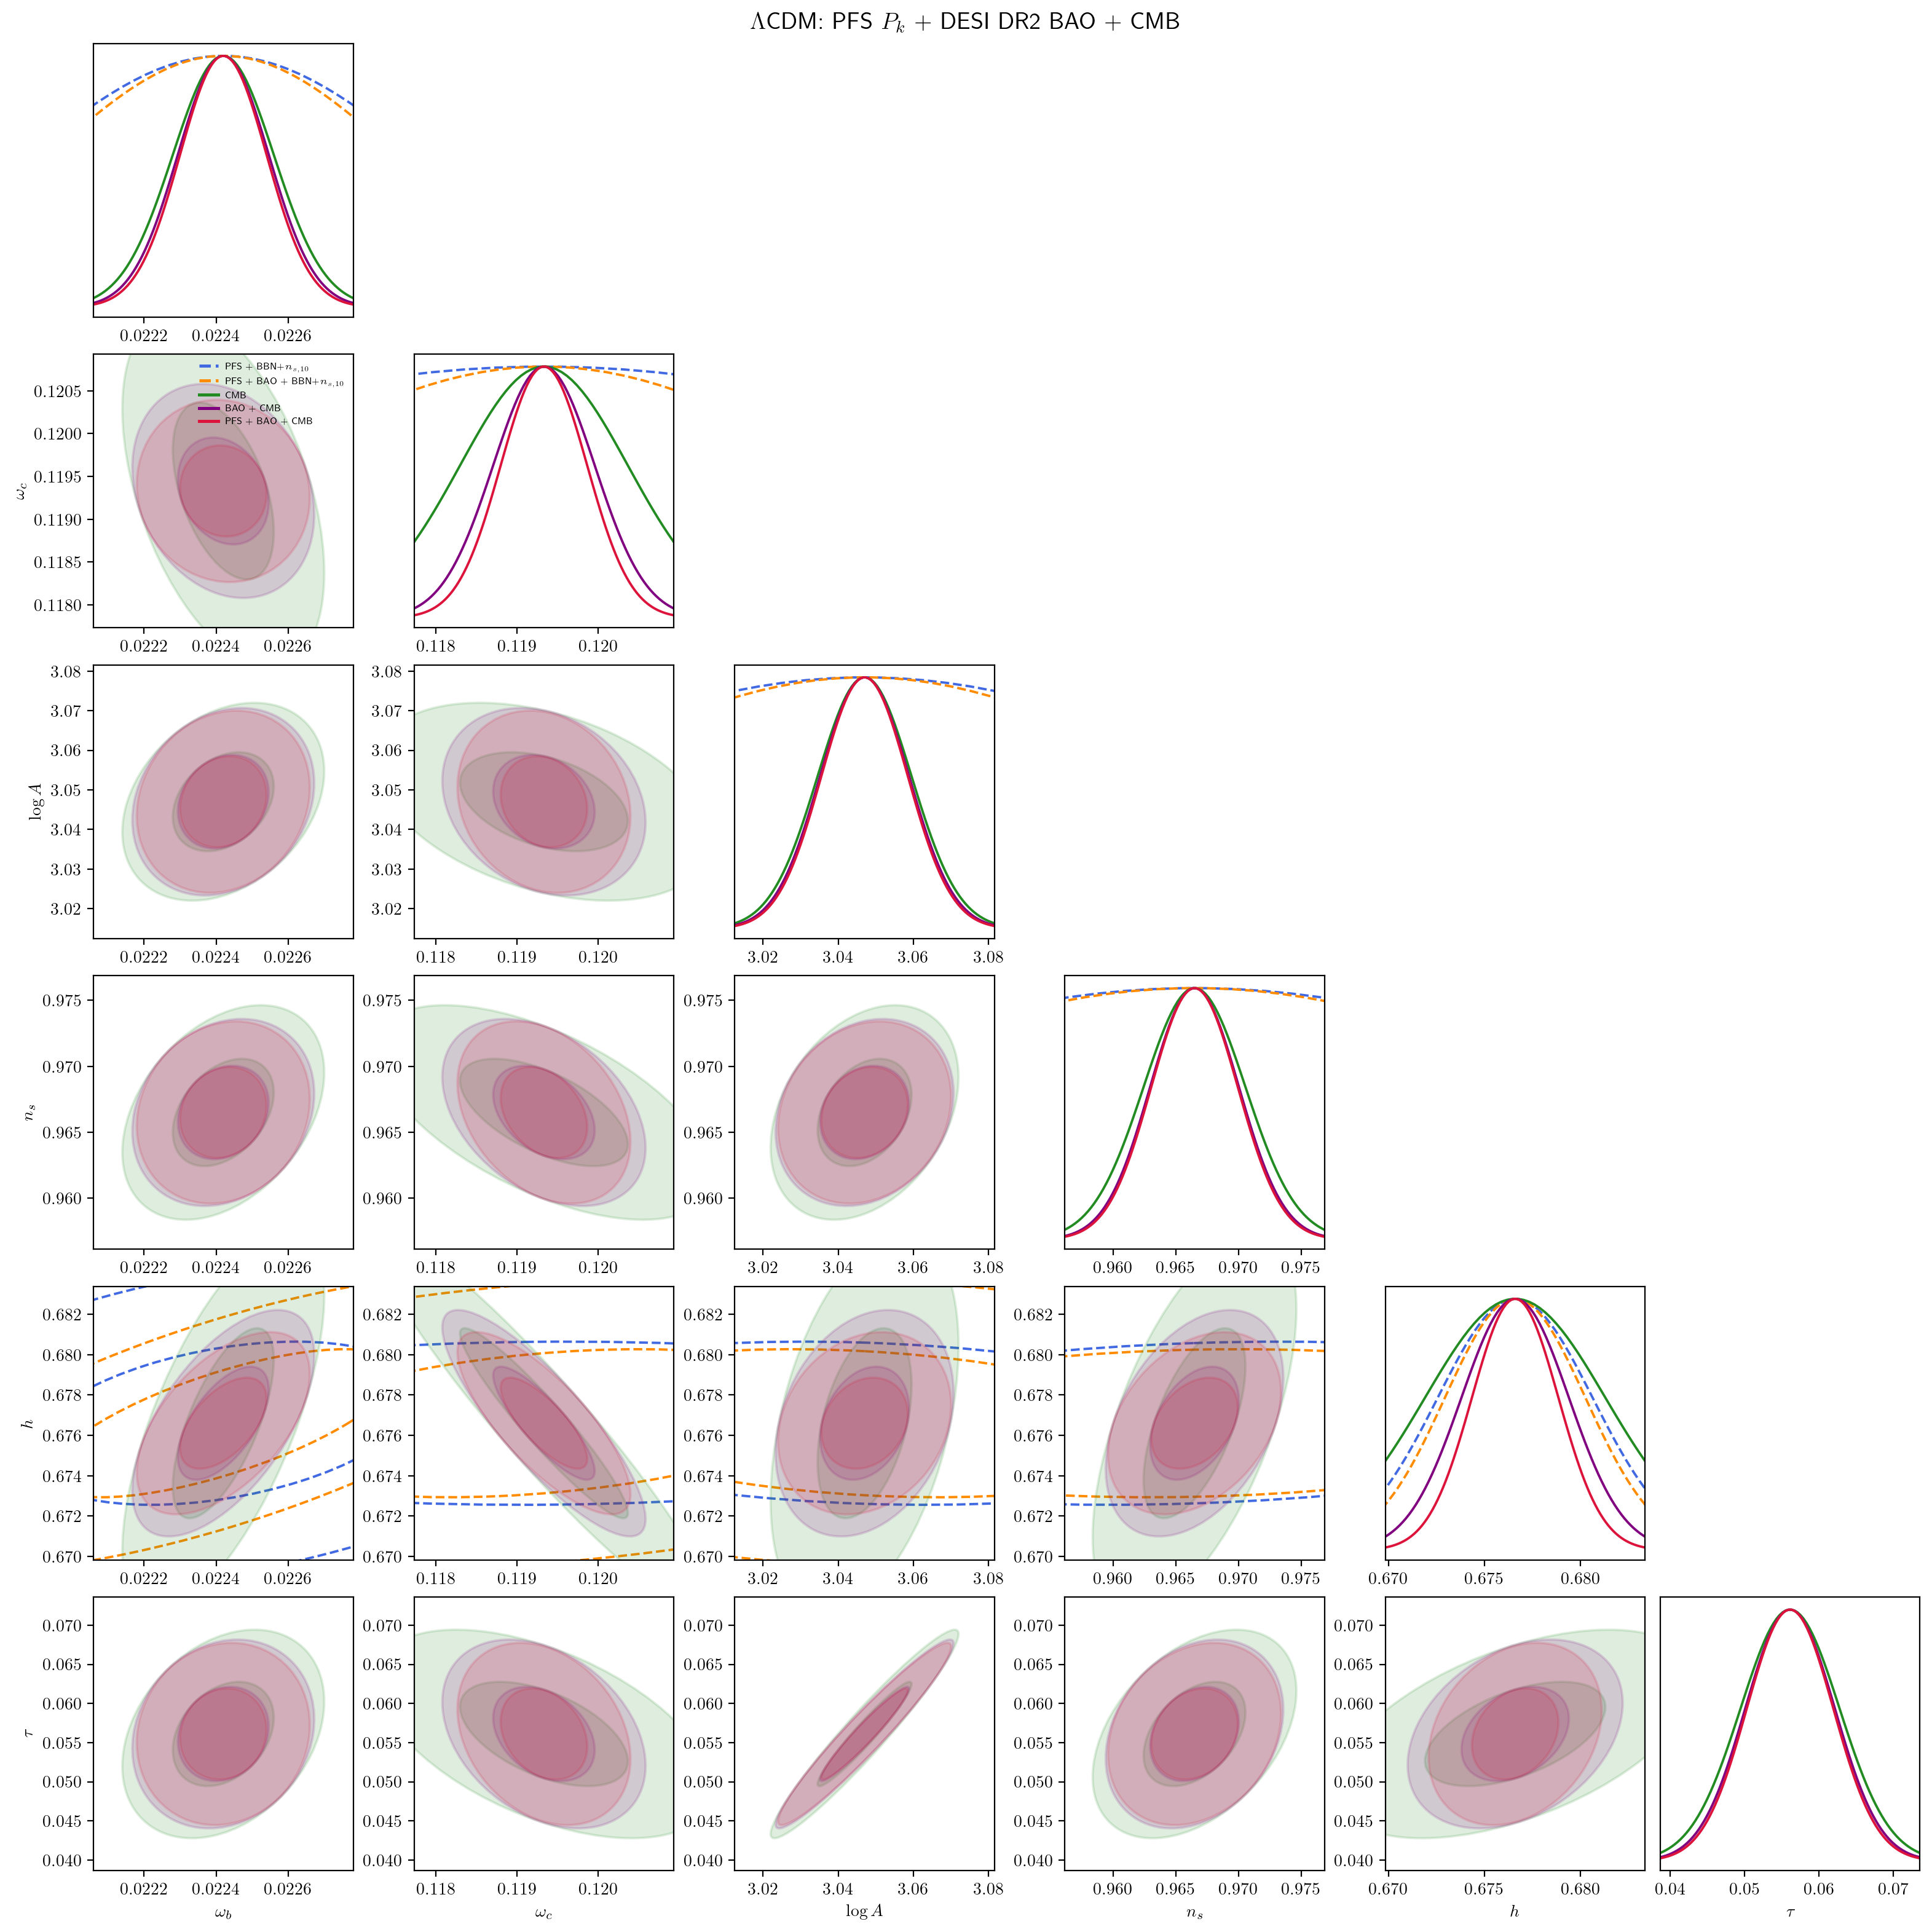

In [12]:
plot_cases = [
    (r'PFS + BBN+$n_{s,10}$',       F_pfs_prior_shared,     'royalblue',  '--', False),
    (r'PFS + BAO + BBN+$n_{s,10}$', F_pfs_bao_prior_shared, 'darkorange', '--', False),
    (r'CMB',             F_cmb_shared,     'forestgreen', '-',  True),
    (r'BAO + CMB',       F_bao_cmb_shared, 'purple',      '-',  True),
    (r'PFS + BAO + CMB', F_joint,          'crimson',     '-',  True),
]

plt.rcParams.update({"font.size": 10})
fig = plt.figure(figsize=(N_SHARED * 2.6, N_SHARED * 2.6), constrained_layout=True)

legend_handles = [
    mlines.Line2D([], [], color=c, ls=ls, lw=1.8, label=lbl)
    for lbl, _, c, ls, _ in plot_cases
]

for i in range(N_SHARED):
    for j in range(N_SHARED):
        ax = plt.subplot(N_SHARED, N_SHARED, i * N_SHARED + j + 1)

        if j < i:
            for label, F, color, ls, filled in plot_cases:
                sub = F[np.ix_([j, i], [j, i])]
                if np.linalg.matrix_rank(sub, tol=1e-10) < 2:
                    continue
                try:
                    plot_contours(
                        F, FIDUCIAL_SHARED, np.array([j, i]),
                        ax=ax, fill=filled, color=color, ls=ls, lw=1.4,
                        alpha=0.15 if filled else 1.0,
                    )
                except Exception:
                    pass
            if i == 1 and j == 0:
                ax.legend(handles=legend_handles, fontsize=5.5, frameon=False, loc='best')

        elif j == i:
            for label, F, color, ls, filled in plot_cases:
                if F[i, i] < 1e-10:
                    continue
                try:
                    plot_Gaussian(F, FIDUCIAL_SHARED, i, ax=ax, color=color, ls=ls, lw=1.4)
                except Exception:
                    pass
            ax.set_yticks([])

        else:
            ax.axis('off')

        if i == N_SHARED - 1:
            ax.set_xlabel(SHARED_LABELS[j])
        if j == 0 and i > 0:
            ax.set_ylabel(SHARED_LABELS[i])

fig.suptitle(
    MODEL_TITLE + r': PFS $P_k$ + DESI DR2 BAO + CMB',
    fontsize=14,
)

## Fisher diagnostics

In [13]:
print("PFS+BAO+BBN+ns10 Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_pfs_bao_prior_shared, param_names=list(SHARED_KEYS))))

print("PFS+BAO+CMB joint Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_joint, param_names=list(SHARED_KEYS))))
print()
print("BAO+CMB Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_bao_cmb_shared, param_names=list(SHARED_KEYS))))
print()
print("CMB-only Fisher diagnostics:")
print(format_fisher_diagnostics(fisher_diagnostics(F_cmb_shared, param_names=list(SHARED_KEYS))))

PFS+BAO+BBN+ns10 Fisher diagnostics:
rank=5/6, weak_modes=1, cond=inf, sym_err=0.000e+00, weak_tol=8.907e-04
smallest eigenvalues: 0.000e+00, 1.373e+02, 1.104e+03
null-space participation: tau (1.00)
mode 0 [weak] eig=0.000e+00: tau (+1.000), h (+0.000), ns (+0.000), logA (+0.000)
mode 1 [smallest] eig=1.373e+02: logA (-0.990), ns (-0.138), omch2 (+0.023), h (+0.010)
mode 2 [smallest] eig=1.104e+03: ns (-0.990), logA (+0.138), h (-0.026), omch2 (+0.012)
PFS+BAO+CMB joint Fisher diagnostics:
rank=6/6, weak_modes=0, cond=3.125e+04, sym_err=0.000e+00, weak_tol=1.894e-02
smallest eigenvalues: 6.063e+03, 8.065e+04, 2.338e+05
null-space participation: logA (0.80), tau (0.19)
mode 0 [smallest] eig=6.063e+03: logA (+0.895), tau (+0.441), ns (+0.054), h (+0.039)
mode 1 [smallest] eig=8.065e+04: ns (+0.939), h (+0.311), logA (-0.107), tau (+0.073)
mode 2 [smallest] eig=2.338e+05: h (-0.910), ns (+0.335), omch2 (+0.172), tau (-0.146)

BAO+CMB Fisher diagnostics:
rank=6/6, weak_modes=0, cond=3.311